<a href="https://colab.research.google.com/github/Dragnel25/timeseriesdoan/blob/main/notebooks_01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

=> Đã lưu dữ liệu sạch vào Google Drive của cậu với tên: AEP_cleaned.csv

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,Load
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


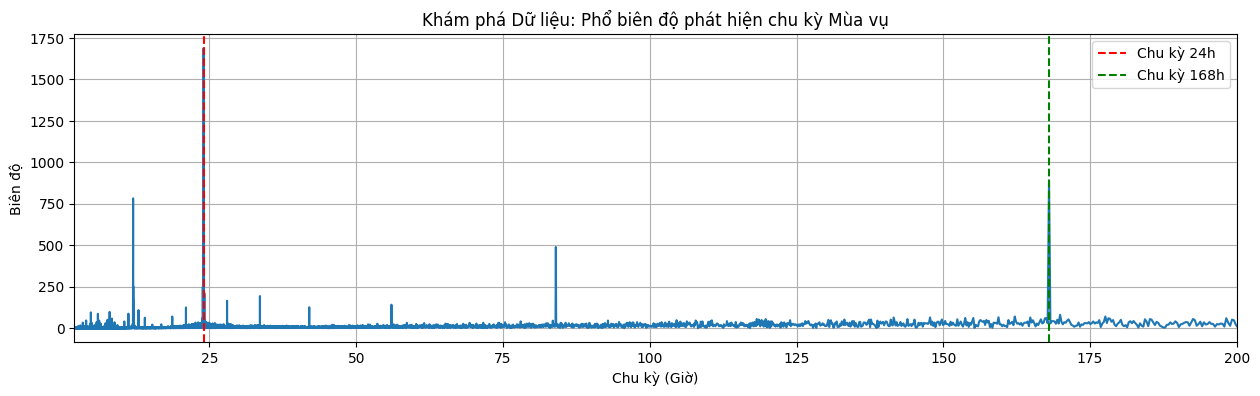

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend
from scipy.fft import rfft, rfftfreq
from google.colab import drive

# 1. ĐỌC DỮ LIỆU TỪ LINK GỐC CỦA CẬU
url = "https://drive.google.com/uc?export=download&id=1SGvpMy-vB7TcKjnvF2T2qlnXgEY4XsGj"
df = pd.read_csv(url)
df.columns = ['Datetime', 'Load']
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Tiền xử lý: Gộp trùng lặp và nội suy
df = df.groupby('Datetime')['Load'].mean().reset_index()
df = df.set_index('Datetime').resample('h').interpolate(method='linear')

# 2. XUẤT FILE SẠCH VÀO DRIVE CÁ NHÂN ĐỂ CHUYỀN CHO FILE 02
drive.mount('/content/drive')
df.to_csv('/content/drive/MyDrive/AEP_cleaned.csv')
print("\n=> Đã lưu dữ liệu sạch vào Google Drive của cậu với tên: AEP_cleaned.csv\n")

print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df.head())

# 3. KHAI PHÁ PHỔ FOURIER
x_detrended = detrend(df['Load'].dropna().values)
N = len(x_detrended)
dt = 1.0
X = rfft(x_detrended)
freqs = rfftfreq(N, d=dt)

amplitude = np.abs(X) / N
if N % 2 == 0: amplitude[1:-1] *= 2
else: amplitude[1:] *= 2

valid = freqs > 0
freqs_v, amplitude_v = freqs[valid], amplitude[valid]
periods_v = 1.0 / freqs_v

# 4. VẼ ĐỒ THỊ EDA
plt.figure(figsize=(15, 4))
plt.plot(periods_v, amplitude_v)
plt.xlim(2, 200)
plt.title("Khám phá Dữ liệu: Phổ biên độ phát hiện chu kỳ Mùa vụ")
plt.xlabel("Chu kỳ (Giờ)")
plt.ylabel("Biên độ")
plt.axvline(24, color='r', linestyle='--', label='Chu kỳ 24h')
plt.axvline(168, color='g', linestyle='--', label='Chu kỳ 168h')
plt.legend()
plt.grid(True)
plt.show()